In [66]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


In [68]:
df = pd.read_csv("../Dataset/kickstarter_projects.csv")

In [69]:
df.head()

,ID,Name,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed


In [70]:
# Standardize Column Names
df.columns = df.columns.str.strip().str.lower()

df.columns

Index(['id', 'name', 'category', 'subcategory', 'country', 'launched',
       'deadline', 'goal', 'pledged', 'backers', 'state'],
      dtype='object')

In [71]:
df.columns = df.columns.str.strip().str.lower()

In [72]:
df.info

<bound method DataFrame.info of                 id                                               name  \
0       1860890148  Grace Jones Does Not Give A F$#% T-Shirt (limi...   
1        709707365                     CRYSTAL ANTLERS UNTITLED MOVIE   
2       1703704063                                drawing for dollars   
3           727286                       Offline Wikipedia iPhone app   
4       1622952265                                         Pantshirts   
...            ...                                                ...   
374848  1486845240                  Americas Got Talent - Serious MAK   
374849   974738310  EVO Planner: The World's First Personalized Fl...   
374850  2106246194    Help save La Gattara, Arizona's first Cat Cafe!   
374851  1830173355                                Digital Dagger Coin   
374852  1339173863                              Spirits of the Forest   

            category     subcategory        country             launched  \
0            Fa

In [73]:
print("Rows:", df.shape[0])
print("Columns:", df.shape [1])

Rows: 374853
Columns: 11


In [74]:
df.columns

Index(['id', 'name', 'category', 'subcategory', 'country', 'launched',
       'deadline', 'goal', 'pledged', 'backers', 'state'],
      dtype='object')

In [75]:
df.isnull().sum()

id             0
name           0
category       0
subcategory    0
country        0
launched       0
deadline       0
goal           0
pledged        0
backers        0
state          0
dtype: int64

In [83]:
df.duplicated().sum()

0

In [85]:
df.describe()

,id,goal,pledged,backers
count,3.748530e+05,3.748530e+05,3.748530e+05,374853.000000
mean,1.074656e+09,4.586378e+04,9.121073e+03,106.690359
std,6.191377e+08,1.158778e+06,9.132054e+04,911.718520
min,5.971000e+03,0.000000e+00,0.000000e+00,0.000000
25%,5.380728e+08,2.000000e+03,3.100000e+01,2.000000
50%,1.075300e+09,5.500000e+03,6.250000e+02,12.000000
75%,1.610149e+09,1.600000e+04,4.051000e+03,57.000000
max,2.147476e+09,1.663614e+08,2.033899e+07,219382.000000


In [86]:
print("Categories :", df["category"].nunique())
print("Subcategories :", df["subcategory"].nunique())
print("Countries :", df["country"].nunique())
print("States :", df["state"].nunique())

Categories : 15
Subcategories : 159
Countries : 22
States : 5


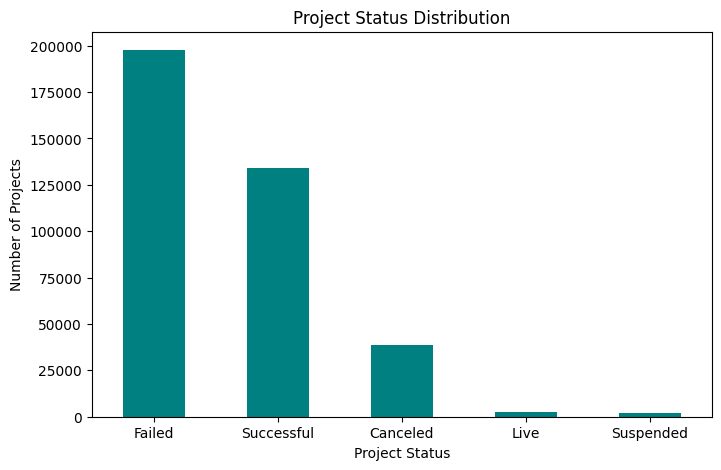

In [102]:
# Project Status Distribution

status_counts = df["state"].value_counts()

plt.figure(figsize=(8,5))
status_counts.plot(kind="bar", color="teal")
plt.title("Project Status Distribution")
plt.xlabel("Project Status")
plt.ylabel("Number of Projects")
plt.xticks(rotation=0)
plt.show()

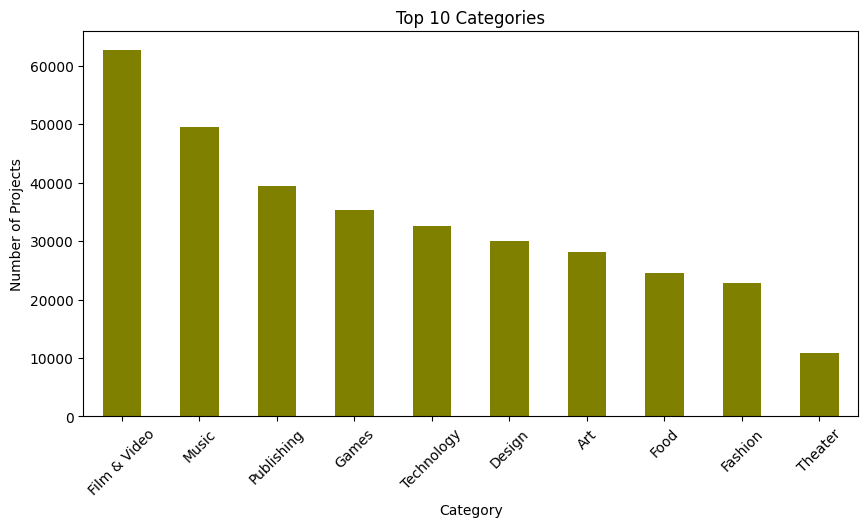

In [112]:
# Top 10 Categories

top_categories = df["category"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_categories.plot(kind="bar",color="olive")
plt.title("Top 10 Categories")
plt.xlabel("Category")
plt.ylabel("Number of Projects")
plt.xticks(rotation=45)
plt.show()


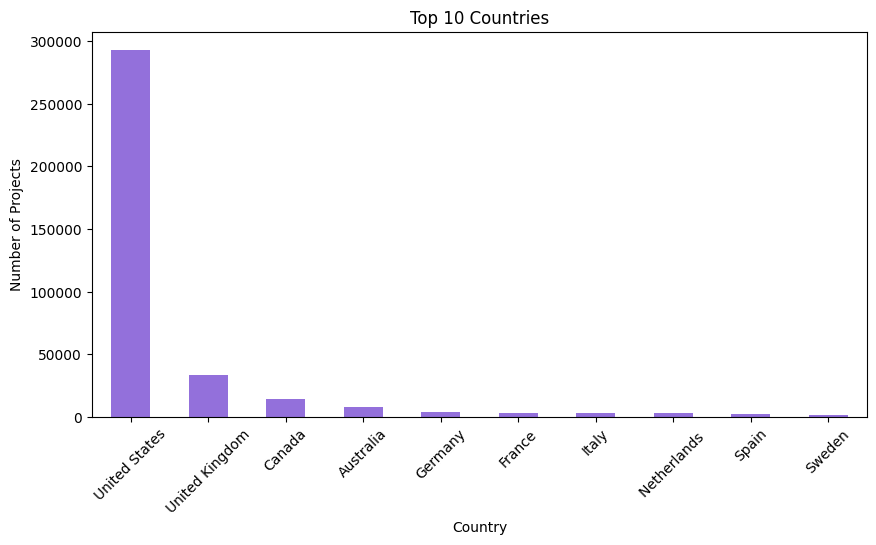

In [106]:
# Top 10 Countries

top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind="bar",color="mediumpurple")
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Projects")
plt.xticks(rotation=45)
plt.show()

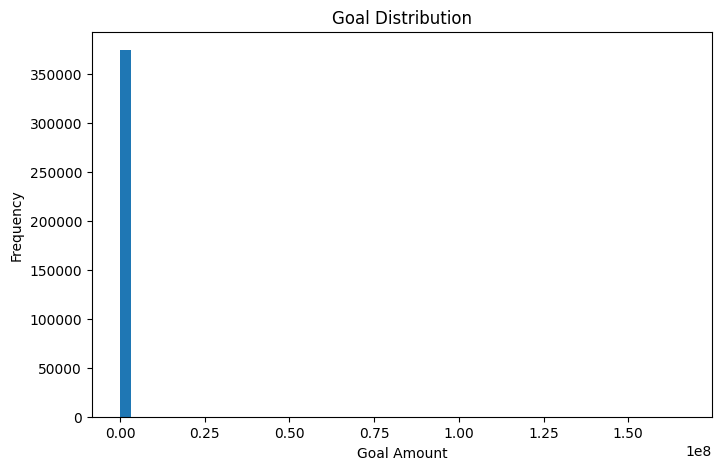

In [108]:
# Goal Distribution

plt.figure(figsize=(8,5))
plt.hist(df["goal"], bins=50,)
plt.title("Goal Distribution")
plt.xlabel("Goal Amount")
plt.ylabel("Frequency")
plt.show()

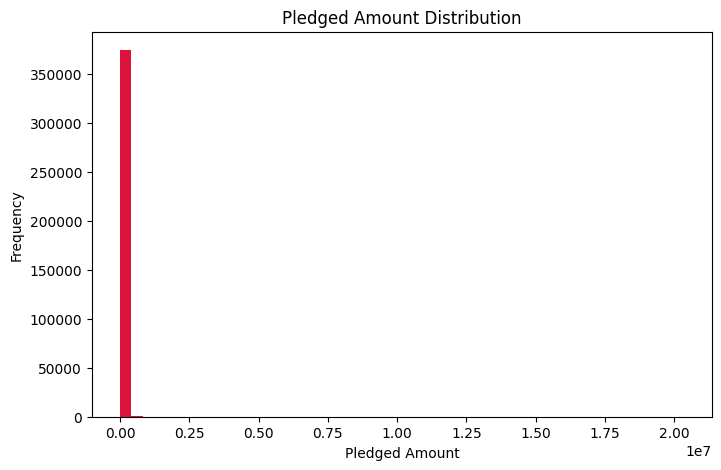

In [110]:
# Pledged Distribution

plt.figure(figsize=(8,5))
plt.hist(df["pledged"], bins=50, color="crimson")
plt.title("Pledged Amount Distribution")
plt.xlabel("Pledged Amount")
plt.ylabel("Frequency")
plt.show()

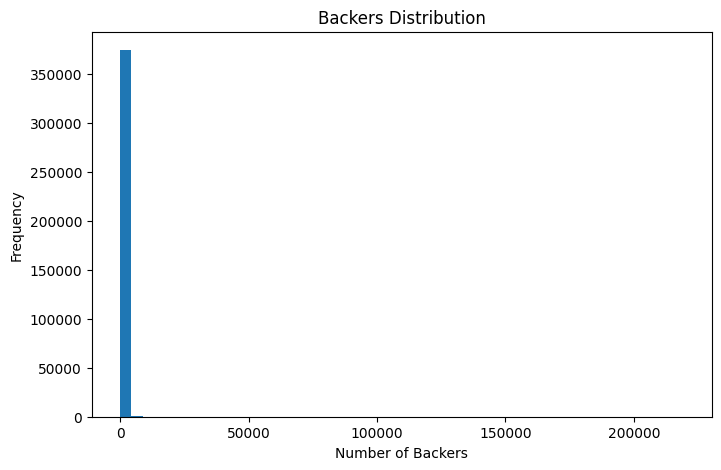

In [100]:
# Backers Distribution

plt.figure(figsize=(8,5))
plt.hist(df["backers"], bins=50)
plt.title("Backers Distribution")
plt.xlabel("Number of Backers")
plt.ylabel("Frequency")
plt.show()

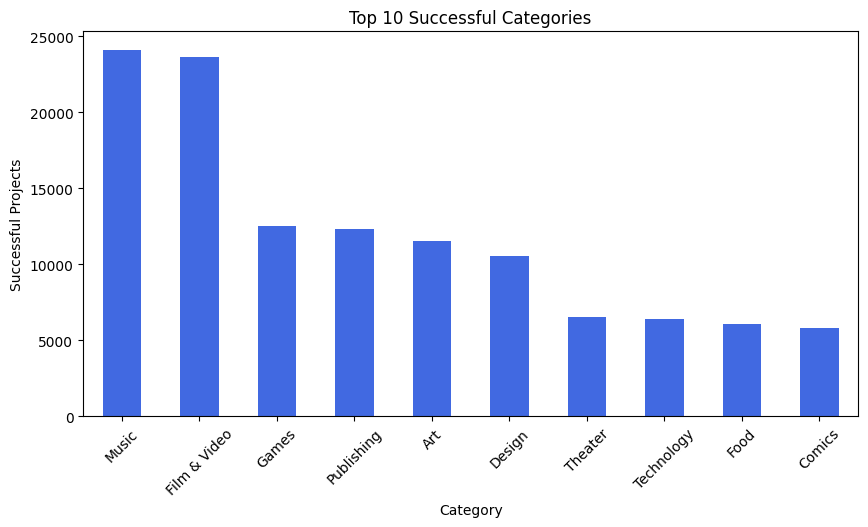

In [114]:
# Top 10 Successful Categories

successful = (
    df[df["state"] == "Successful"]["category"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))
successful.plot(kind="bar", color="royalblue")
plt.title("Top 10 Successful Categories")
plt.xlabel("Category")
plt.ylabel("Successful Projects")
plt.xticks(rotation=45)
plt.show()


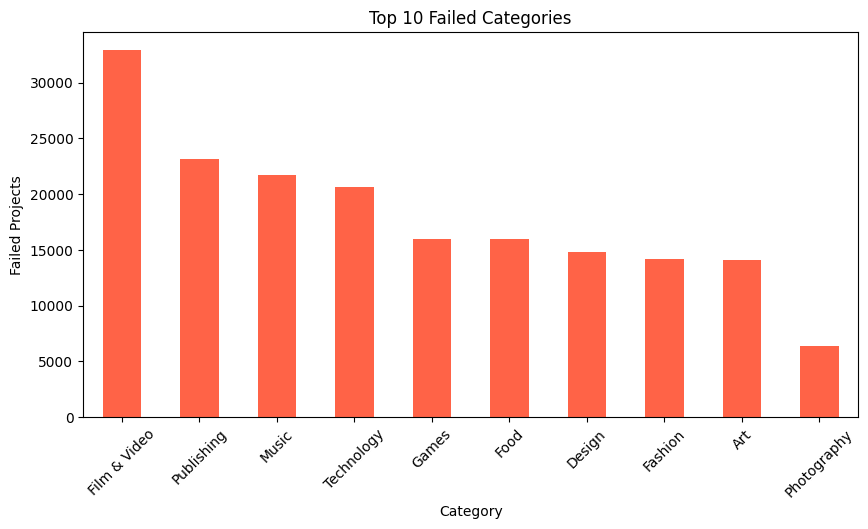

In [116]:
# Top 10 Failed Categories

failed = (
    df[df["state"] == "Failed"]["category"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))
failed.plot(kind="bar", color="tomato")
plt.title("Top 10 Failed Categories")
plt.xlabel("Category")
plt.ylabel("Failed Projects")
plt.xticks(rotation=45)
plt.show()

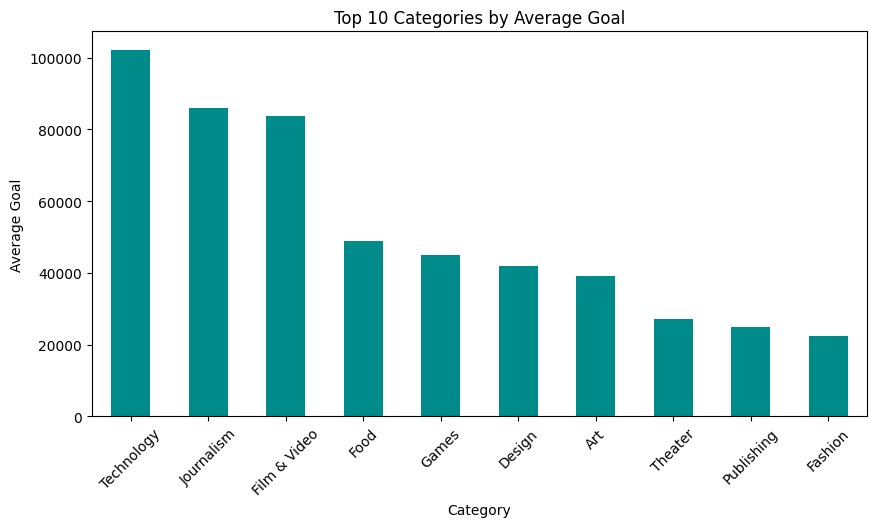

In [118]:
# Average Goal by Category

avg_goal = (
    df.groupby("category")["goal"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
avg_goal.plot(kind="bar", color="darkcyan")
plt.title("Top 10 Categories by Average Goal")
plt.xlabel("Category")
plt.ylabel("Average Goal")
plt.xticks(rotation=45)
plt.show()

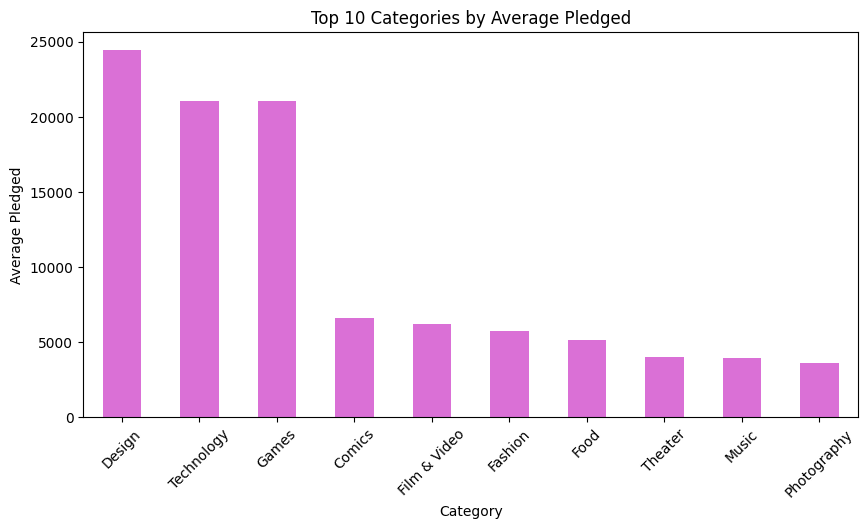

In [134]:
# Average Pledged by Category

avg_pledged = (
    df.groupby("category")["pledged"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
avg_pledged.plot(kind="bar", color="orchid")
plt.title("Top 10 Categories by Average Pledged")
plt.xlabel("Category")
plt.ylabel("Average Pledged")
plt.xticks(rotation=45)
plt.show()

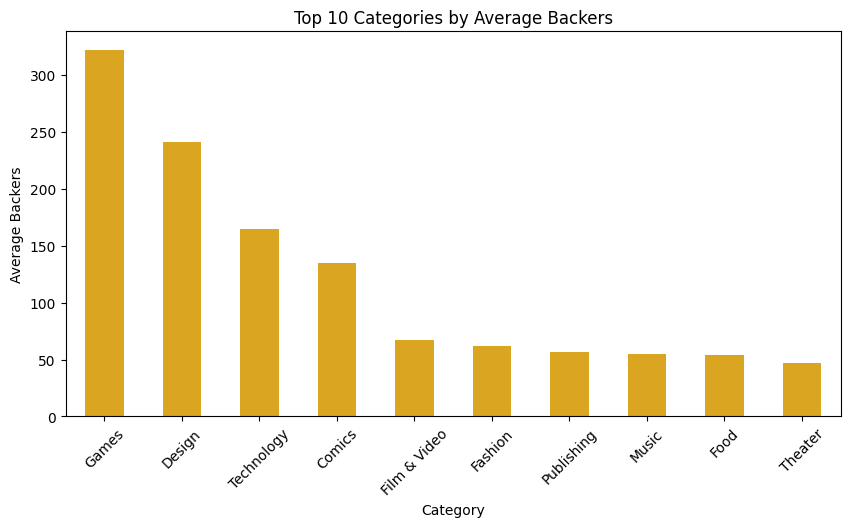

In [122]:
# Average Backers by Category

avg_backers = (
    df.groupby("category")["backers"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
avg_backers.plot(kind="bar", color="goldenrod")
plt.title("Top 10 Categories by Average Backers")
plt.xlabel("Category")
plt.ylabel("Average Backers")
plt.xticks(rotation=45)
plt.show()

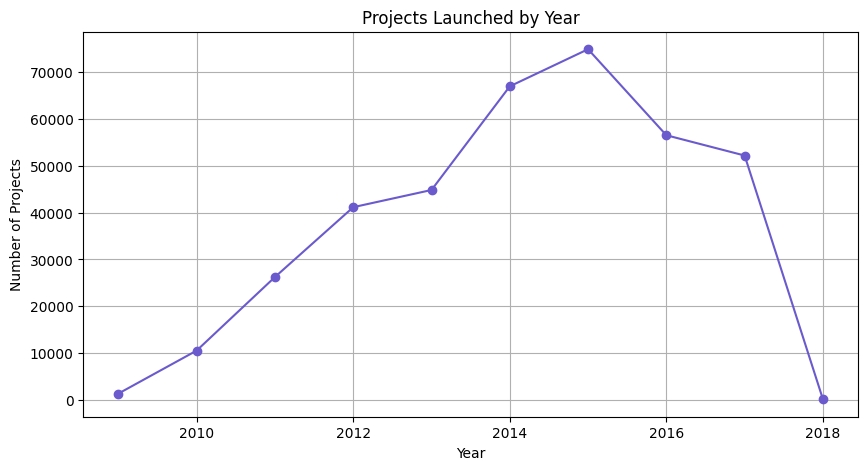

In [136]:
# Projects Launched by Year

df["launched"] = pd.to_datetime(df["launched"])

launch_year = df["launched"].dt.year.value_counts().sort_index()

plt.figure(figsize=(10,5))
launch_year.plot(kind="line", marker="o", color="slateblue")
plt.title("Projects Launched by Year")
plt.xlabel("Year")
plt.ylabel("Number of Projects")
plt.grid(True)
plt.show()

In [138]:
# Correlation Matrix

corr = df[["goal", "pledged", "backers"]].corr()

print(corr)

             goal   pledged   backers
goal     1.000000  0.005566  0.004476
pledged  0.005566  1.000000  0.753449
backers  0.004476  0.753449  1.000000


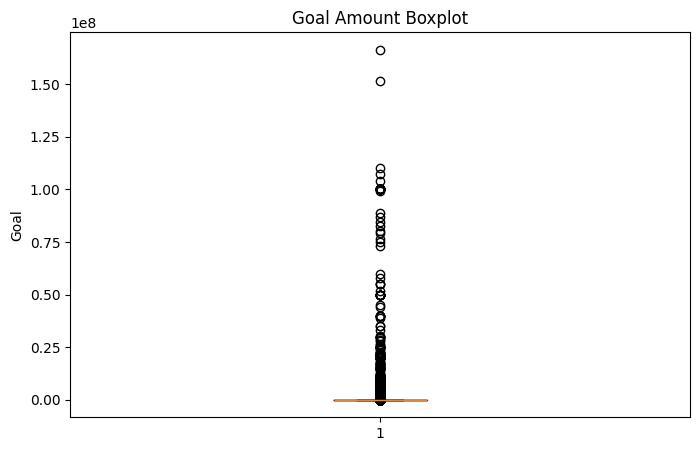

In [140]:
# Goal Boxplot

plt.figure(figsize=(8,5))
plt.boxplot(df["goal"])
plt.title("Goal Amount Boxplot")
plt.ylabel("Goal")
plt.show()

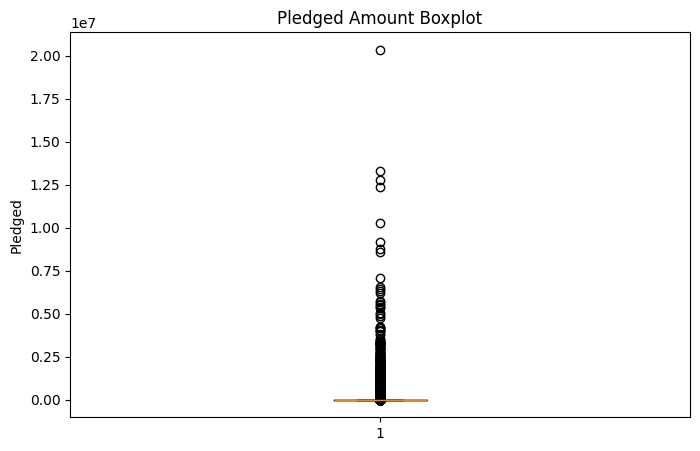

In [142]:
# Pledged Boxplot

plt.figure(figsize=(8,5))
plt.boxplot(df["pledged"])
plt.title("Pledged Amount Boxplot")
plt.ylabel("Pledged")
plt.show()

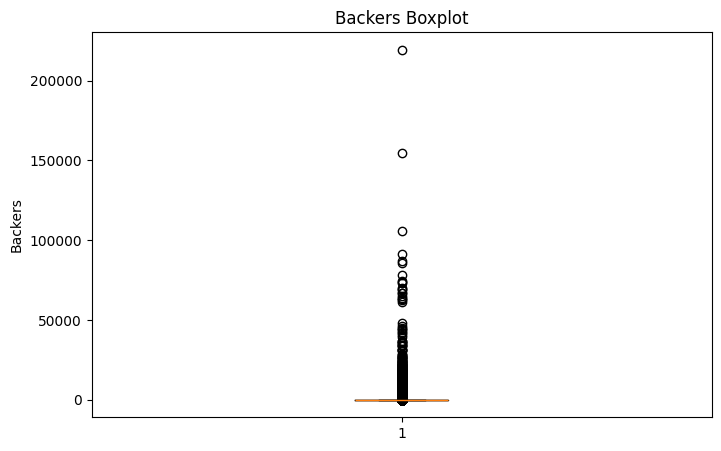

In [144]:
# Backers Boxplot

plt.figure(figsize=(8,5))
plt.boxplot(df["backers"])
plt.title("Backers Boxplot")
plt.ylabel("Backers")
plt.show()

# Key Business Insights

- The dataset contains 374,853 crowdfunding projects across multiple countries and categories.
- The United States has the highest number of Kickstarter projects.
- Film & Video and Music are the most popular categories.
- Dance has the highest project success rate among major categories.
- Games and Design attract the highest average number of backers.
- Successful projects receive significantly more backers than failed projects.
- Funding goals and pledged amounts contain several high-value outliers.

# Conclusion

This project demonstrates an end-to-end data analytics workflow using Python, SQL, and Power BI.

The analysis explores project performance, funding trends, category-wise success, country distribution, and backer behavior. The insights generated can help creators understand which project categories perform well and identify factors associated with successful crowdfunding campaigns.